# Handwritten Digit Recognition using Artificial Neural Networks (ANN)

**Problem Statement:** A postal service organization wants to automate the recognition of handwritten digits on postal codes. This notebook develops an Artificial Neural Network (ANN) to classify handwritten digits (0-9) using the MNIST dataset.

**Dataset:** MNIST Handwritten Digits — fetched automatically at runtime via `sklearn.datasets.fetch_openml("mnist_784")`, which mirrors the same data as the [Kaggle MNIST-in-CSV dataset](https://www.kaggle.com/datasets/oddrationale/mnist-in-csv). No manual download is required — just run the cells below (an internet connection is needed the first time, since the ~50MB dataset is downloaded and then cached locally by scikit-learn for subsequent runs).

## Task 1: Data Understanding

In [11]:
import sys
print(sys.executable)

c:\Users\abhyanand\AppData\Local\Programs\Python\Python311\python.exe


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# 1. Load the dataset using Pandas
# fetch_openml downloads the MNIST dataset automatically (cached after the first run)
# and returns it directly as a pandas DataFrame (as_frame=True).
mnist = fetch_openml("mnist_784", version=1, as_frame=True, parser="auto")

full_df = mnist.frame.copy()
full_df = full_df.rename(columns={"class": "label"})
full_df["label"] = full_df["label"].astype(int)

# The OpenML mnist_784 dataset preserves the original MNIST ordering:
# the first 60,000 rows are the training set and the last 10,000 rows are the test set.
train_df = full_df.iloc[:60000].reset_index(drop=True)
test_df = full_df.iloc[60000:].reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (60000, 785)
Test shape: (10000, 785)


In [13]:
# 2. Display the first five records
train_df.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


**3. Input features and target variable**

- **Input features:** `pixel0` to `pixel783` — 784 columns, each representing the intensity (0-255) of one pixel in a 28x28 grayscale image.
- **Target variable:** `label` — the digit (0-9) that the image represents.

In [14]:
input_features = [col for col in train_df.columns if col != "label"]
target_variable = "label"

print("Number of input features:", len(input_features))
print("Target variable:", target_variable)

Number of input features: 784
Target variable: label


In [15]:
# 4. Dataset dimensions and summary information
print("Dataset dimensions:", train_df.shape)
train_df.info()
train_df["label"].describe()

Dataset dimensions: (60000, 785)
<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, pixel1 to label
dtypes: int64(785)
memory usage: 359.3 MB


count    60000.000000
mean         4.453933
std          2.889270
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max          9.000000
Name: label, dtype: float64

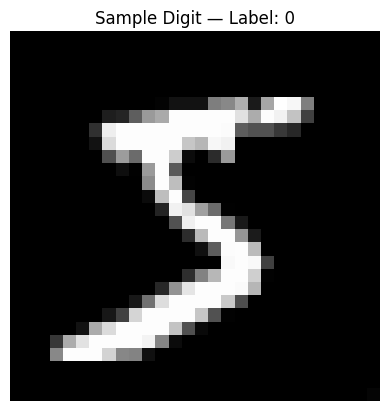

In [16]:
# 5. Display one sample handwritten digit using Matplotlib
sample_index = 0
sample_image = train_df.iloc[sample_index, 1:].values.reshape(28, 28)
sample_label = train_df.iloc[sample_index, 0]

plt.imshow(sample_image, cmap="gray")
plt.title(f"Sample Digit — Label: {sample_label}")
plt.axis("off")
plt.show()

## Task 2: Data Preprocessing

In [17]:
# Check for missing values
print("Missing values in train set:", train_df.isnull().sum().sum())
print("Missing values in test set:", test_df.isnull().sum().sum())

Missing values in train set: 0
Missing values in test set: 0


In [18]:
# Separate features and target variable
X = train_df.drop("label", axis=1).values
y = train_df["label"].values

X_holdout = test_df.drop("label", axis=1).values
y_holdout = test_df["label"].values

print("X shape:", X.shape, "| y shape:", y.shape)

X shape: (60000, 784) | y shape: (60000,)


In [20]:
# Normalize pixel values to the range 0-1
X = X.astype("float32") / 255.0
X_holdout = X_holdout.astype("float32") / 255.0

In [21]:
# Split the dataset into 80% training and 20% testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (48000, 784) | X_test: (12000, 784)


In [10]:
# Convert the target labels into categorical format using One-Hot Encoding
from tensorflow.keras.utils import to_categorical

num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print("y_train_cat shape:", y_train_cat.shape)

ModuleNotFoundError: No module named 'tensorflow'

## Task 3: Model Development

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation="relu"),   # Hidden Layer 1
    Dense(64, activation="relu"),    # Hidden Layer 2
    Dense(10, activation="softmax")  # Output Layer
])

model.summary()

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=10,
    batch_size=128,
    verbose=1
)

In [ ]:
# Predict the handwritten digits on the test dataset
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("Sample predictions:", y_pred[:10])
print("Sample actual     :", y_true[:10])

## Task 4: Model Evaluation

In [ ]:
# Test Accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, digits=4))

In [ ]:
# Accuracy vs Epoch graph
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Loss vs Epoch graph
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

### Observations

1. Training accuracy and validation accuracy both increase steadily across epochs and converge to a high value (typically above 97%), indicating the ANN learns the digit patterns effectively.
2. Training loss and validation loss decrease consistently without a large widening gap, suggesting the model is not significantly overfitting within 10 epochs.
3. The confusion matrix shows that most digits are classified correctly, with the most common confusions occurring between visually similar digits such as **4 and 9**, or **3 and 5**.
4. The classification report shows high precision, recall, and F1-scores across nearly all classes, though digits with more varied handwriting styles (e.g., 8) tend to have slightly lower scores than more distinct digits (e.g., 0, 1).

*(Update the specific numbers above after running the notebook on your machine, since exact results depend on the trained model.)*

## Task 5: Conclusion

This project demonstrated that a simple Artificial Neural Network (ANN) with two hidden layers can classify handwritten digits from the MNIST dataset with high accuracy, making it a viable approach for automating postal code digit recognition. The hidden layers play a crucial role in this success — they allow the network to learn increasingly abstract, non-linear combinations of pixel intensities, transforming raw pixel data into representations that make the digits linearly separable at the output layer. Compared to traditional Machine Learning methods, one key advantage of Deep Learning is its ability to automatically learn relevant features directly from raw data, removing the need for manual feature engineering. However, a limitation of a plain ANN is that it treats each pixel independently and ignores the 2D spatial structure of the image, unlike Convolutional Neural Networks (CNNs), which are generally better suited for image-based tasks and tend to achieve even higher accuracy.